# EPG Spatial Transfer Diagnostics

This notebook diagnoses why the spatial random-forest workflow is weak for `EPG heating` and `EPG cooling`. It reads the latest saved training outputs and does not retrain the random forests.

The diagnosis focuses on four questions:

1. Does the trained model beat simple train-mean baselines under the same fixed-test and spatial-CV roles?
2. Are EPG target distributions and prediction biases shifted by NUTS3 region?
3. Where are large residuals located geographically?
4. Which allowed predictors are important or remain correlated with residual errors?


In [1]:
from __future__ import annotations

import json
import sys
from importlib import import_module, reload
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import TwoSlopeNorm
from sklearn.metrics import mean_absolute_error, r2_score

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
try:
    from IPython.display import display
except Exception:
    display = print

EPG_TARGETS = ["EPG heating", "EPG cooling"]

In [2]:
REPO_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "pipeline" / "config").exists()
)
sys.path.append(str(REPO_ROOT))

from pipeline.utils.paths import load_paths, path_value, repo_data_path

rf_utils = reload(import_module("pipeline.3_epvi_prediction.utils"))
PATHS = load_paths()
MODEL_OUT_DIR = path_value(PATHS, "external_data_root") / "outputs" / "epvi_prediction" / "random_forest"
PARISH_GEOMETRY_GEOJSON = repo_data_path(PATHS, "parishes.geojson")

metrics_path = rf_utils.latest_file(MODEL_OUT_DIR, "rf_epvi_metrics_*.csv")
if metrics_path is None:
    raise FileNotFoundError(f"No RF metrics found in {MODEL_OUT_DIR}. Run model_training.ipynb first.")
stamp = metrics_path.stem.removeprefix("rf_epvi_metrics_")
predictions_path = MODEL_OUT_DIR / f"rf_epvi_predictions_residuals_{stamp}.csv"
importances_path = MODEL_OUT_DIR / f"rf_epvi_feature_importances_{stamp}.csv"
params_path = MODEL_OUT_DIR / f"rf_epvi_best_params_{stamp}.json"
folds_path = MODEL_OUT_DIR / f"rf_epvi_spatial_cv_folds_{stamp}.csv"
required = [metrics_path, predictions_path, importances_path, params_path, folds_path]
missing = [path for path in required if not path.exists()]
if missing:
    raise FileNotFoundError(f"Latest RF output stamp {stamp} is incomplete: {missing}")

print("output stamp:", stamp)
for path in required:
    print(" -", path)

output stamp: 20260522_001417
 - E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\epvi_prediction\random_forest\rf_epvi_metrics_20260522_001417.csv
 - E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\epvi_prediction\random_forest\rf_epvi_predictions_residuals_20260522_001417.csv
 - E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\epvi_prediction\random_forest\rf_epvi_feature_importances_20260522_001417.csv
 - E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\epvi_prediction\random_forest\rf_epvi_best_params_20260522_001417.json
 - E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\epvi_prediction\random_forest\rf_epvi_spatial_cv_folds_20260522_001417.csv


In [3]:
metrics = pd.read_csv(metrics_path)
predictions = pd.read_csv(predictions_path)
importances = pd.read_csv(importances_path)
folds = pd.read_csv(folds_path)
with open(params_path, "r", encoding="utf-8") as f:
    best_params = json.load(f)

epg_metrics = metrics[metrics["target"].isin(EPG_TARGETS)].copy()
epg_predictions = predictions[predictions["target"].isin(EPG_TARGETS)].copy()
epg_importances = importances[importances["target"].isin(EPG_TARGETS)].copy()
epg_folds = folds[folds["target"].eq(EPG_TARGETS[0])].copy()

display(epg_metrics[[
    "target", "n_train_rows", "n_test_rows", "search_spatial_cv_r2_mean",
    "train_spatial_cv_r2", "fixed_test_r2", "fixed_test_rmse", "fixed_test_spearman",
]])
display(pd.DataFrame(best_params).T.loc[EPG_TARGETS])
display(epg_folds)

,target,n_train_rows,n_test_rows,search_spatial_cv_r2_mean,train_spatial_cv_r2,fixed_test_r2,fixed_test_rmse,fixed_test_spearman
3,EPG heating,2658,434,0.039766,0.215703,0.053922,1.689632,0.314364
4,EPG cooling,2658,434,-0.033641,0.132475,-0.861937,0.982949,0.221397


,model__n_estimators,model__min_samples_split,model__min_samples_leaf,model__max_features,model__max_depth
EPG heating,600.0,30.0,12.0,0.2,6.0
EPG cooling,600.0,30.0,8.0,0.2,4.0


,target,fold,n_rows,n_nuts3,validation_nuts3
0,EPG heating,0,514,4,"PT11A, PT150, PT170, PT200"
1,EPG heating,1,570,6,"PT11B, PT11C, PT16H, PT16I, PT187, PT300"
2,EPG heating,2,514,4,"PT11D, PT16D, PT16F, PT16G"
3,EPG heating,3,544,5,"PT111, PT119, PT181, PT185, PT186"
4,EPG heating,4,516,4,"PT112, PT11E, PT16B, PT184"


## Baseline Check

A weak random forest can still be useful if it beats a baseline. The fixed-test baseline predicts the training-set target mean. The spatial-CV baseline predicts each held-out NUTS3 fold from the mean of the remaining training folds.

In [4]:
fold_by_nuts3 = {}
for row in epg_folds.itertuples(index=False):
    for nuts3 in row.validation_nuts3.split(", "):
        fold_by_nuts3[nuts3] = int(row.fold)

def role_metrics(target: str, role: str, observed, predicted, predictor_name: str) -> dict:
    return {
        "target": target,
        "prediction_role": role,
        "predictor": predictor_name,
        "n": len(observed),
        "r2": r2_score(observed, predicted),
        "mae": mean_absolute_error(observed, predicted),
        "rmse": rf_utils.rmse(observed, predicted),
        "mean_error": float(np.mean(observed - predicted)),
    }

baseline_rows = []
baseline_prediction_frames = []
for target in EPG_TARGETS:
    cv_t = epg_predictions.query("target == @target and prediction_role == 'train_spatial_cv'").copy()
    cv_t["fold"] = cv_t["NUTS3"].map(fold_by_nuts3)
    cv_t["baseline"] = np.nan
    for fold in sorted(cv_t["fold"].dropna().unique()):
        cv_t.loc[cv_t["fold"].eq(fold), "baseline"] = cv_t.loc[~cv_t["fold"].eq(fold), "observed"].mean()
    test_t = epg_predictions.query("target == @target and prediction_role == 'fixed_test'").copy()
    test_t["baseline"] = cv_t["observed"].mean()
    for role, data_t in [("train_spatial_cv", cv_t), ("fixed_test", test_t)]:
        baseline_rows.append(role_metrics(target, role, data_t["observed"], data_t["predicted"], "random_forest"))
        baseline_rows.append(role_metrics(target, role, data_t["observed"], data_t["baseline"], "train_mean_baseline"))
        baseline_prediction_frames.append(data_t.assign(prediction_role=role))

baseline_metrics = pd.DataFrame(baseline_rows)
baseline_predictions = pd.concat(baseline_prediction_frames, ignore_index=True)
display(baseline_metrics.sort_values(["target", "prediction_role", "predictor"]))

,target,prediction_role,predictor,n,r2,mae,rmse,mean_error
6,EPG cooling,fixed_test,random_forest,434,-0.861937,0.895416,0.982949,0.657800
7,EPG cooling,fixed_test,train_mean_baseline,434,-1.616915,1.097111,1.165315,0.915993
4,EPG cooling,train_spatial_cv,random_forest,2658,0.132475,0.724245,0.995531,-0.077805
5,EPG cooling,train_spatial_cv,train_mean_baseline,2658,-0.100582,0.840716,1.121309,0.002055
2,EPG heating,fixed_test,random_forest,434,0.053922,1.028053,1.689632,-0.201205
3,EPG heating,fixed_test,train_mean_baseline,434,-0.001498,1.180530,1.738416,0.067240
0,EPG heating,train_spatial_cv,random_forest,2658,0.215703,1.013778,1.554598,-0.143974
1,EPG heating,train_spatial_cv,train_mean_baseline,2658,-0.124153,1.254953,1.861190,0.004994


## Prediction Compression and Target Shift

These plots show whether the random forest collapses regional predictions toward the training mean and whether fixed-test target distributions are shifted relative to the spatial-CV training regions.

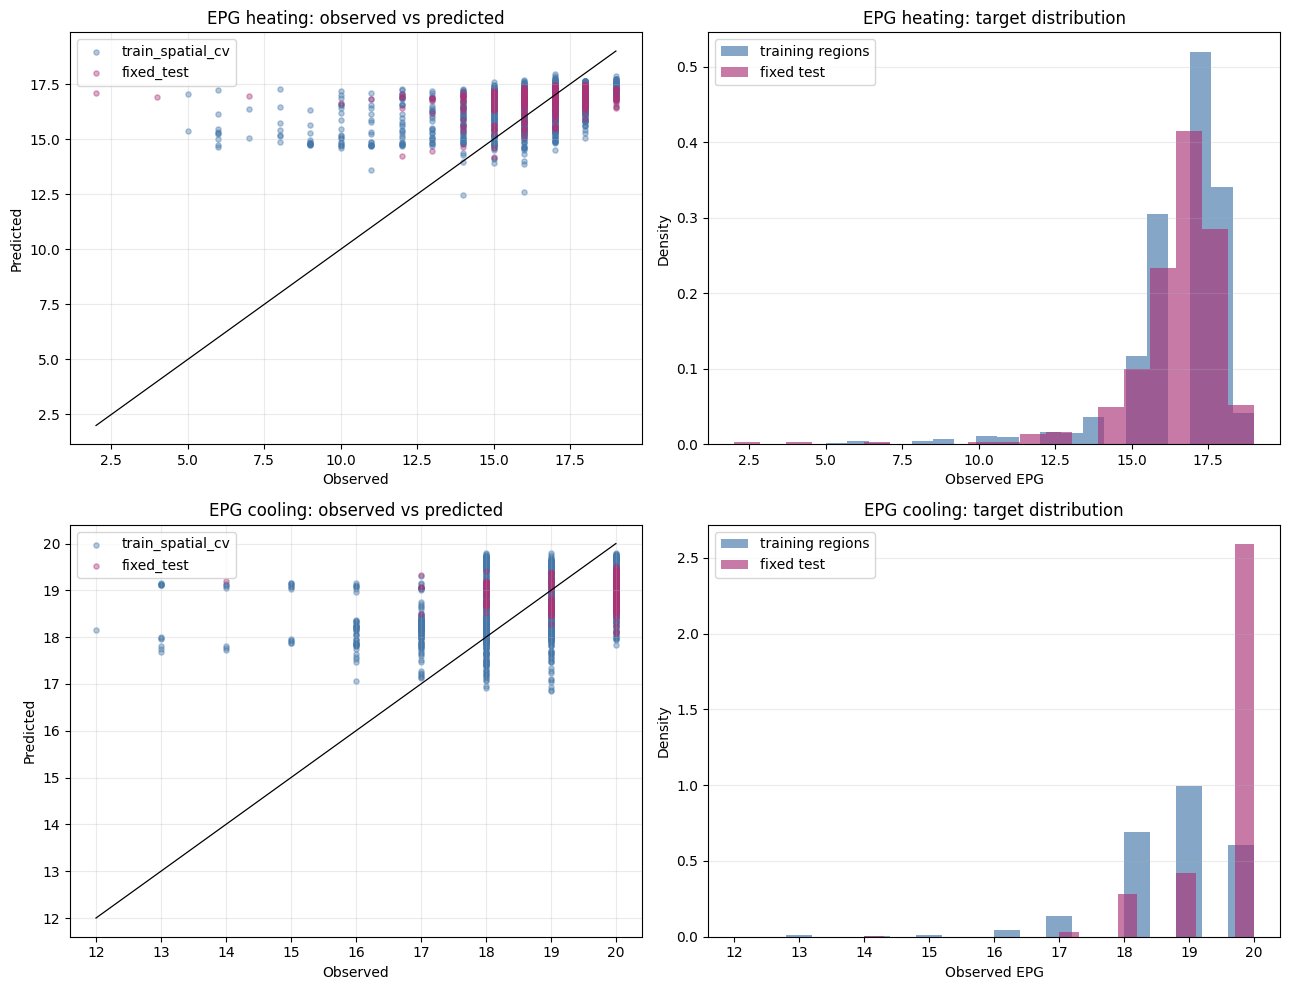

observed                             predicted  \
                                  min       mean   max       std        min   
target      prediction_role                                                   
EPG cooling fixed_test           14.0  19.661290  20.0  0.721190  18.096551   
            train_in_sample      12.0  18.745297  20.0  1.069044  16.449166   
            train_spatial_cv     12.0  18.745297  20.0  1.069044  16.845326   
EPG heating fixed_test            2.0  16.605991  19.0  1.739120  14.209225   
            train_in_sample       5.0  16.538751  19.0  1.755738  10.424800   
            train_spatial_cv      5.0  16.538751  19.0  1.755738  12.486874   

                                                              
                                   mean        max       std  
target      prediction_role                                   
EPG cooling fixed_test        19.003491  19.520167  0.276605  
            train_in_sample   18.746746  19.651060  0.597605  
            train_spatial_cv  18.823102  19.797470  0.530015  
EPG heating fixed_test        16.807196  17.524630  0.514574  
            train_in_sample   16.541000  18.045105  1.084726  
            train_spatial_cv  16.682725  17.949798  0.663528

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for row, target in enumerate(EPG_TARGETS):
    ax = axes[row, 0]
    for role, color in [("train_spatial_cv", "#4477AA"), ("fixed_test", "#AA3377")]:
        part = epg_predictions.query("target == @target and prediction_role == @role")
        ax.scatter(part["observed"], part["predicted"], s=14, alpha=0.4, label=role, color=color)
    lo = epg_predictions.loc[epg_predictions["target"].eq(target), ["observed", "predicted"]].min().min()
    hi = epg_predictions.loc[epg_predictions["target"].eq(target), ["observed", "predicted"]].max().max()
    ax.plot([lo, hi], [lo, hi], color="black", linewidth=0.9)
    ax.set_title(f"{target}: observed vs predicted")
    ax.set_xlabel("Observed")
    ax.set_ylabel("Predicted")
    ax.grid(alpha=0.25)
    ax.legend()

    ax = axes[row, 1]
    train_vals = epg_predictions.query("target == @target and prediction_role == 'train_spatial_cv'")["observed"]
    test_vals = epg_predictions.query("target == @target and prediction_role == 'fixed_test'")["observed"]
    ax.hist(train_vals, bins=20, alpha=0.65, density=True, label="training regions", color="#4477AA")
    ax.hist(test_vals, bins=20, alpha=0.65, density=True, label="fixed test", color="#AA3377")
    ax.set_title(f"{target}: target distribution")
    ax.set_xlabel("Observed EPG")
    ax.set_ylabel("Density")
    ax.grid(axis="y", alpha=0.25)
    ax.legend()
plt.tight_layout()
plt.show()

range_summary = epg_predictions.groupby(["target", "prediction_role"])[["observed", "predicted"]].agg(["min", "mean", "max", "std"])
display(range_summary)

## Region-Level Errors

Region means expose systematic NUTS3 biases that parish-level scatter plots can hide. Negative mean residuals are overprediction; positive mean residuals are underprediction.

,target,prediction_role,NUTS3,n,observed_mean,predicted_mean,residual_mean,mae,rmse
0,EPG cooling,fixed_test,PT16E,168.0,19.797619,18.827888,0.969731,0.972709,1.056097
1,EPG cooling,fixed_test,PT16J,266.0,19.575188,19.114398,0.460790,0.846599,0.933803
10,EPG cooling,train_spatial_cv,PT150,67.0,15.477612,18.344065,-2.866453,2.870949,3.440111
17,EPG cooling,train_spatial_cv,PT170,118.0,17.516949,18.325793,-0.808844,1.069246,1.301345
13,EPG cooling,train_spatial_cv,PT16F,67.0,19.477612,18.312058,1.165554,1.165554,1.275745
8,EPG cooling,train_spatial_cv,PT11D,217.0,18.290323,19.362460,-1.072137,1.103688,1.217845
20,EPG cooling,train_spatial_cv,PT185,68.0,17.441176,18.276737,-0.835560,1.017221,1.112769
19,EPG cooling,train_spatial_cv,PT184,62.0,18.387097,17.443282,0.943815,0.943815,1.099656
12,EPG cooling,train_spatial_cv,PT16D,74.0,19.094595,18.122494,0.972101,0.984896,1.047894
14,EPG cooling,train_spatial_cv,PT16G,156.0,19.929487,19.077813,0.851674,0.895412,0.994417


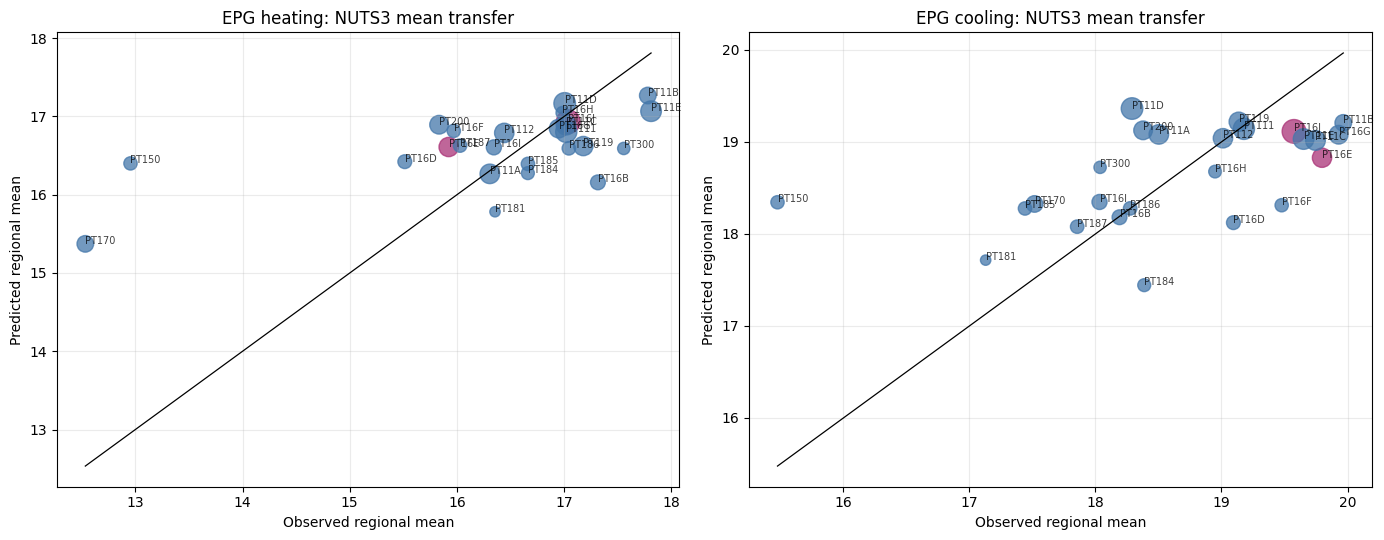

In [6]:
def regional_metrics(df: pd.DataFrame) -> pd.Series:
    return pd.Series({
        "n": len(df),
        "observed_mean": df["observed"].mean(),
        "predicted_mean": df["predicted"].mean(),
        "residual_mean": df["residual"].mean(),
        "mae": df["residual"].abs().mean(),
        "rmse": rf_utils.rmse(df["observed"], df["predicted"]),
    })

region_summary = (
    epg_predictions[epg_predictions["prediction_role"].isin(["train_spatial_cv", "fixed_test"])]
    .groupby(["target", "prediction_role", "NUTS3"], observed=True)
    .apply(regional_metrics, include_groups=False)
    .reset_index()
)
display(region_summary.sort_values(["target", "prediction_role", "rmse"], ascending=[True, True, False]).head(30))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, target in zip(axes, EPG_TARGETS):
    part = region_summary[region_summary["target"].eq(target)].copy()
    colors = part["prediction_role"].map({"train_spatial_cv": "#4477AA", "fixed_test": "#AA3377"})
    ax.scatter(part["observed_mean"], part["predicted_mean"], s=25 + part["n"], alpha=0.75, c=colors)
    lo = part[["observed_mean", "predicted_mean"]].min().min()
    hi = part[["observed_mean", "predicted_mean"]].max().max()
    ax.plot([lo, hi], [lo, hi], color="black", linewidth=0.9)
    for row in part.itertuples(index=False):
        ax.annotate(row.NUTS3, (row.observed_mean, row.predicted_mean), fontsize=7, alpha=0.75)
    ax.set_title(f"{target}: NUTS3 mean transfer")
    ax.set_xlabel("Observed regional mean")
    ax.set_ylabel("Predicted regional mean")
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Residual Maps

The maps use the same mainland-plus-insets layout as the index choropleths. Training maps show spatial-CV residuals in training regions. Fixed-test maps show residuals only in `PT16E` and `PT16J`.

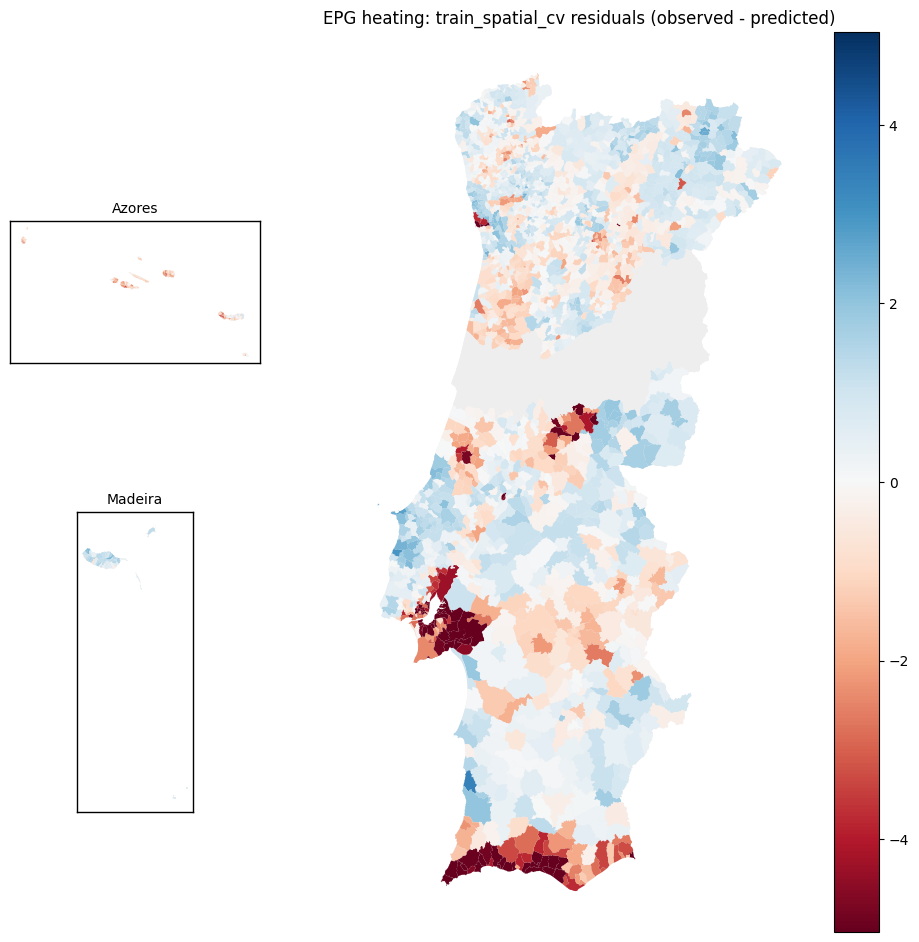

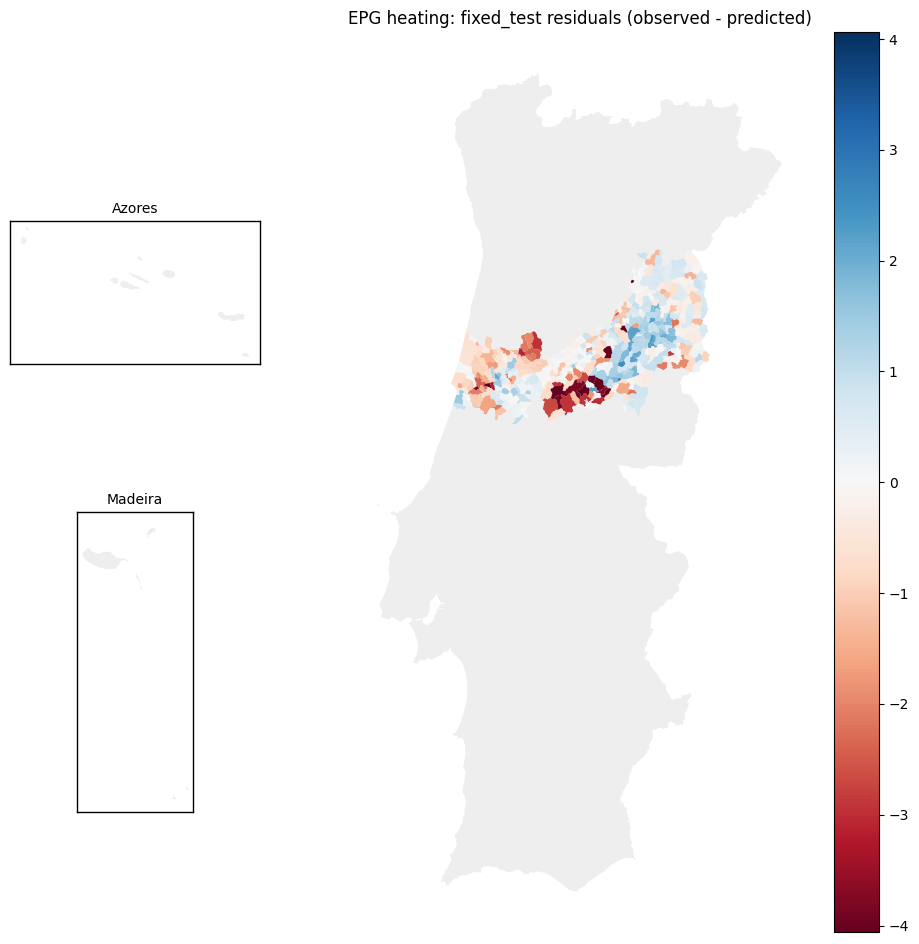

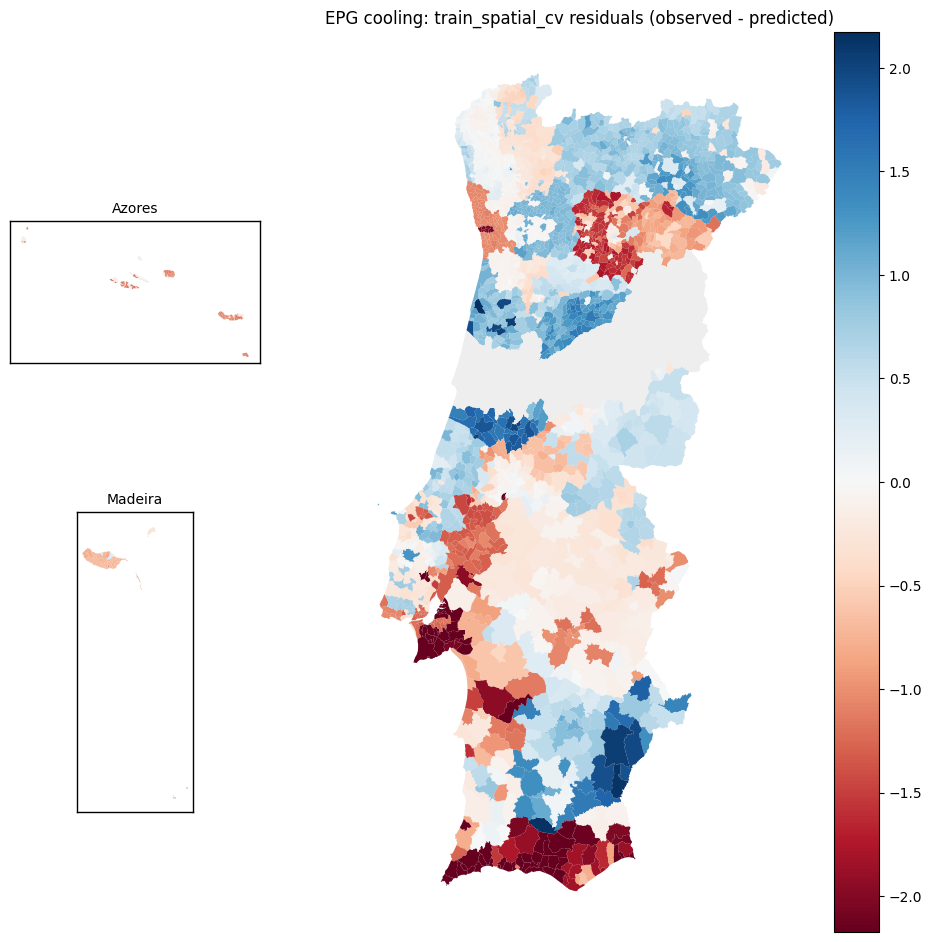

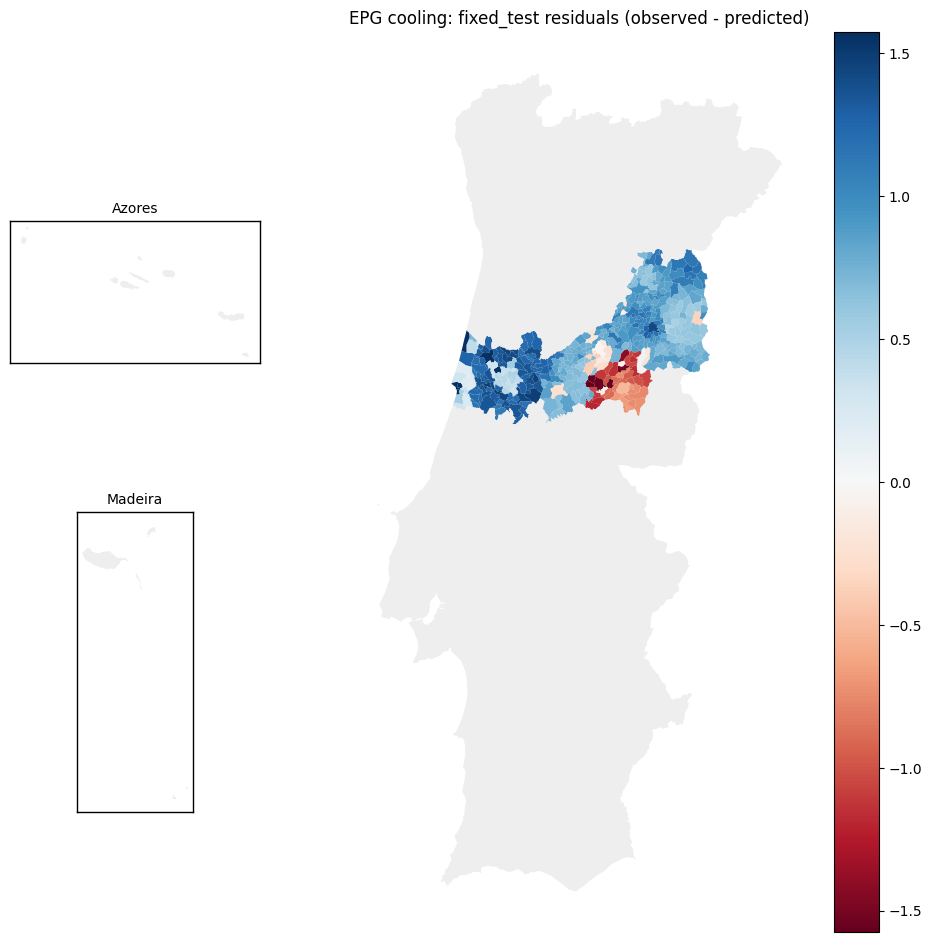

In [7]:
parishes = gpd.read_file(PARISH_GEOMETRY_GEOJSON)[["dicofre", "geometry"]].copy()
parishes["ID_norm"] = rf_utils.normalize_id(parishes["dicofre"])
nuts3_mapping = rf_utils.load_nuts3_mapping(repo_data_path(PATHS, "freguesias_to_NUTS3.csv"))
parishes = parishes.merge(nuts3_mapping, on="ID_norm", how="left")

def add_bounds(ax, gdf):
    minx, miny, maxx, maxy = gdf.total_bounds
    padx = (maxx - minx) * 0.05 if maxx > minx else 1
    pady = (maxy - miny) * 0.05 if maxy > miny else 1
    ax.set_xlim(minx - padx, maxx + padx)
    ax.set_ylim(miny - pady, maxy + pady)
    ax.set_xticks([])
    ax.set_yticks([])

def residual_map(target: str, role: str):
    residuals = epg_predictions.query("target == @target and prediction_role == @role")[["ID_norm", "residual"]]
    gdf = parishes.merge(residuals, on="ID_norm", how="left")
    mainland = gdf.loc[~gdf["NUTS3"].isin(["PT200", "PT300"])].copy()
    azores = gdf.loc[gdf["NUTS3"].eq("PT200")].copy()
    madeira = gdf.loc[gdf["NUTS3"].eq("PT300")].copy()
    nuts3_boundaries = {
        "mainland": mainland.dissolve(by="NUTS3").boundary,
        "azores": azores.dissolve(by="NUTS3").boundary,
        "madeira": madeira.dissolve(by="NUTS3").boundary,
    }
    finite = gdf["residual"].dropna().abs()
    limit = max(float(finite.quantile(0.98)) if not finite.empty else 1.0, 0.1)
    norm = TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit)
    fig = plt.figure(figsize=(10, 10))
    ax_main = fig.add_axes([0.33, 0.05, 0.64, 0.90])
    ax_azores = fig.add_axes([0.05, 0.54, 0.25, 0.30], frameon=True)
    ax_madeira = fig.add_axes([0.05, 0.17, 0.25, 0.30], frameon=True)
    for ax, part, boundary_key, legend in [(ax_main, mainland, "mainland", True), (ax_azores, azores, "azores", False), (ax_madeira, madeira, "madeira", False)]:
        part.plot(ax=ax, color="#eeeeee", linewidth=0)
        part.plot(ax=ax, column="residual", cmap="RdBu", norm=norm, legend=legend, linewidth=0, missing_kwds={"color": "#eeeeee"})
        nuts3_boundaries[boundary_key].plot(ax=ax, color="black", linewidth=0.55, zorder=20)
        add_bounds(ax, part)
        ax.set_facecolor("white")
    ax_main.set_axis_off()
    ax_main.set_title(f"{target}: {role} residuals (observed - predicted)")
    ax_azores.set_title("Azores", fontsize=10)
    ax_madeira.set_title("Madeira", fontsize=10)
    for ax in [ax_azores, ax_madeira]:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color("black")
            spine.set_linewidth(1.0)
    plt.show()

for target in EPG_TARGETS:
    residual_map(target, "train_spatial_cv")
    residual_map(target, "fixed_test")

## Predictor and Residual Diagnostics

Impurity importance describes the final training-fit forest, not causality. Residual correlations below ask a different question: which allowed predictors still align with EPG errors under spatial transfer?

In [8]:
SAT_CSV, _, _ = rf_utils.choose_satellite_csv(PATHS, repo_data_path, path_value)
inputs = rf_utils.load_prediction_inputs(
    sat_csv=SAT_CSV,
    adm_csv=repo_data_path(PATHS, "all_used_adm_indicators.csv"),
    epvi_csv=path_value(PATHS, "epvi_csv"),
    adm_split_json=repo_data_path(PATHS, "adm_data_split.json"),
)
model_df, predictor_cols, _ = rf_utils.build_modeling_table(inputs)
model_df = rf_utils.attach_nuts3(model_df, nuts3_mapping)

for target in EPG_TARGETS:
    print("\n", target)
    display(epg_importances[epg_importances["target"].eq(target)].nlargest(15, "impurity_importance"))

residual_feature_rows = []
for target in EPG_TARGETS:
    for role in ["train_spatial_cv", "fixed_test"]:
        part = epg_predictions.query("target == @target and prediction_role == @role")[["ID_norm", "residual"]]
        joined = part.merge(model_df[["ID_norm", *predictor_cols]], on="ID_norm", how="left")
        for feature in predictor_cols:
            corr = joined[["residual", feature]].corr(method="spearman").iloc[0, 1]
            residual_feature_rows.append({"target": target, "prediction_role": role, "feature": feature, "residual_spearman": corr})
residual_feature_corr = pd.DataFrame(residual_feature_rows)
residual_feature_corr["abs_residual_spearman"] = residual_feature_corr["residual_spearman"].abs()
display(
    residual_feature_corr.sort_values("abs_residual_spearman", ascending=False)
    .groupby(["target", "prediction_role"], as_index=False, observed=True)
    .head(12)
)


 EPG heating


,target,feature,impurity_importance
0,EPG heating,extreme_cold,0.174940
1,EPG heating,hdd_18,0.099122
2,EPG heating,av_built_up_density,0.081939
3,EPG heating,share_of_superior_edu,0.071716
4,EPG heating,age_x_height,0.071400
5,EPG heating,age_x_res_vol,0.067055
6,EPG heating,av_h,0.047931
7,EPG heating,pop_density,0.039109
8,EPG heating,av_1_over_h,0.033917
9,EPG heating,delta_oc_per_capita,0.020414



 EPG cooling


,target,feature,impurity_importance
46,EPG cooling,extreme_cold,0.259590
47,EPG cooling,hdd_18,0.233767
48,EPG cooling,cdd_25,0.108172
49,EPG cooling,extreme_heat,0.071205
50,EPG cooling,av_built_up_density,0.031597
51,EPG cooling,standard_delta_bc,0.028596
52,EPG cooling,standard_delta_oc,0.028154
53,EPG cooling,delta_oc_per_capita,0.026764
54,EPG cooling,share_of_superior_edu,0.022217
55,EPG cooling,res_ratio,0.020971


,target,prediction_role,feature,residual_spearman,abs_residual_spearman
87,EPG heating,fixed_test,extreme_cold,-0.370898,0.370898
167,EPG cooling,fixed_test,delta_pm_25,0.341183,0.341183
168,EPG cooling,fixed_test,standard_delta_pm_25,0.335869,0.335869
85,EPG heating,fixed_test,cdd_25,0.335764,0.335764
176,EPG cooling,fixed_test,hdd_18,-0.334192,0.334192
86,EPG heating,fixed_test,extreme_heat,0.333100,0.333100
180,EPG cooling,fixed_test,share_of_population_under_4_years_old,0.288524,0.288524
174,EPG cooling,fixed_test,standard_delta_oc,0.287415,0.287415
171,EPG cooling,fixed_test,standard_delta_bc,0.286542,0.286542
181,EPG cooling,fixed_test,share_of_population_over_64_years_old,-0.262166,0.262166


## Readout Checklist

- If EPG random forests do not beat the mean baselines in fixed test or spatial CV, stop narrowing RF hyperparameters.
- If NUTS3 regional means are badly shifted or compressed, compare target distributions and consider explicit spatial baselines or region-transfer framing.
- If residual maps show contiguous regional errors, treat that as remaining spatial structure not learned from allowed predictors.
- If basic administrative variables dominate the EPG residual correlations, separate satellite-only and basic-admin-only baselines before interpreting satellite predictability.
